# Does the sleeping alligator really wake up right before it eats? 🐊💤
### The Gator Oscillator — a color-coded histogram built from a folk indicator, tested on its own terms

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Catches_trend_starts%3F: Busted](https://img.shields.io/badge/Catches_trend_starts%3F-Busted-8b949e?style=flat-square)

Bill Williams' **Alligator** is three wiggly, overlapping moving-average lines that are supposed to represent a sleepy alligator's jaw, teeth and lips. The **Gator Oscillator** turns that mess of lines into something simpler to eyeball: two little bar charts that go **green when the lines are spreading apart** (the mouth is opening — hungry, ready to eat a trend) and **red when they're converging** (the mouth is shut — asleep, nothing happening).

The trading idea is irresistibly simple: *wait for the gator to sleep for a while, then the moment both bars turn green, jump in — you've caught the trend at the start.* We test exactly that, on real market data, honestly.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** The Gator is literally built from the same three lines as [study 421 (the Alligator)](../../421-williams-alligator/) — same fan, same shifts. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gator_oscillator import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_panel()
    SPY = PANEL["SPY"]
else:
    PANEL = SPY = None
print("real cache present:", HAVE_REAL, "| basket names:",
      (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-03', 'end': '2026-06-30', 'n_names': 30, 'min_sleep': 3, 'event': {1: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': 0.013, 'base': 0.03, 'win': 52.1, 't_welch': -0.17, 't_hac': 0.13, 'p': 0.4682, 'net': -0.088, 'mean_abs': 1.001, 'base_abs': 1.043, 't_abs': -0.83, 'p_abs': 0.7434}, 5: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': -0.009, 'base': 0.233, 'win': 49.5, 't_welch': -1.09, 't_hac': -0.04, 'p': 0.51, 'net': -0.114, 'mean_abs': 2.497, 'base_abs': 2.645, 't_abs': -1.2, 'p_abs': 0.8424}, 10: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': -0.119, 'base': 0.479, 'win': 46.9, 't_welch': -1.88, 't_hac': -0.4, 'p': 0.6342, 'net': -0.229, 'mean_abs': 3.364, 'base_abs': 3.785, 't_abs': -2.41, 'p_abs': 0.9772}, 20: {'n_wake': 346, 'n_dir': 192, 'n_bull': 120, 'n_bear': 72, 'mean': 0.604, 'base': 0.976, 'win': 51.0, 't_welch': -0.73, 't_hac': 1.35, 'p': 0.1356, 'net': 0.484, 'mean_abs': 5.169, 'base_abs': 5.431, 't_abs': -0.99, 'p_abs': 0.8092}}, 'hold_days': 10, 'bh': {'cagr': 8.28, 'sharpe': 0.412, 'vol': 19.32, 'dd': -55.19, 't': 2.42}, 'wake': {'cagr': 4.26, 'sharpe': 2.548, 'vol': 1.64, 'dd': -5.67, 't': 15.22}, 'fan': {'cagr': 2.26, 'sharpe': 0.126, 'vol': 17.69, 'dd': -37.48, 't': 0.75}, 't_wake_vs_bh': -1.16, 't_wake_vs_fan': 0.65, 'placebo_p': 0.512, 'placebo_obs': 2.136, 'n_wakes_spy': 13, 'in_pos_frac': 0.9, 'cost10_cagr': 4.23, 'cost10_sharpe': 2.531, 'syn_null_mean': 0.41, 'syn_null_sd': 0.78, 'syn_null_fire': 0, 'syn_null_seeds': 10, 'syn_planted_t': 3.2, 'syn_planted_welch': 2.54, 'syn_planted_mean': 7.02, 'syn_planted_base': 0.67, 'syn_planted_win': 78.6, 'syn_planted_n': 14, 'fp_basket': '7b64d4cd54dd', 'fp_spy': 'eed0b5d1f41e'}


real cache present: True | basket names: 30


## The answer first

| Question | Answer |
|---|---|
| Does the gator waking up predict which way price goes next? | **No.** Across **346** genuine wake events (a real sleep, not a one-day flicker) on 30 stocks over 26 years, the move *after* a wake looks just like an ordinary day — no horizon (1, 5, 10 or 20 days later) clears the statistical bar. |
| Does it at least predict a *bigger* move is coming, even if not which way? | **No — if anything the opposite.** At the 10-day mark, moves after a wake are *smaller* than average, not bigger. |
| Can you actually trade it? | **It looks amazing, then it doesn't.** A real timer on SPY posts a jaw-dropping Sharpe of **2.55** vs buy-and-hold's **0.41** — but that's a trick of the numbers (it's sitting in cash **90%** of the time). Test it properly and the advantage disappears. |
| So is the Alligator/Gator family completely useless? | The Alligator itself (study 421) at least shows *some* trend-following behavior, even if it doesn't beat a plain moving average. The Gator adds nothing on top of that. |

> A green bar means the alligator's mouth is opening. It doesn't mean there's anything worth eating.

## 1 · The claim

> *"When the Gator's bars are red, the market is consolidating — stay out. The instant both bars turn green together, a new trend is beginning. Get in, ride it in the direction the Alligator's lines are already fanned, and get out when the gator goes back to sleep."*

It's one of the most-taught indicators on retail trading platforms (it ships as a default on MetaTrader). It has an intuitive mechanical story: **the Gator bars are literally just the rate-of-change of the Alligator's own spread** — so a green bar genuinely does mean "the lines are pulling apart faster." The question is whether that geometric fact translates into anything you could trade on.

## 2 · So what?

If the Gator really flags the *start* of a trend, it would be a genuinely useful timing tool — better than just being in the Alligator's fan all the time (study 421's approach), because you'd only take a position right as the move begins instead of riding the whole choppy fan-in/fan-out cycle. That's worth testing properly rather than eyeballing a chart: does watching the color change actually buy you anything over the plain Alligator?

## 3 · How would we even know?

- **A real definition of "waking."** A single-day red-to-green flip on both bars happens on roughly **1 day in 4** — that's not "the market slept, then woke up," that's just noise. We require the mouth to have been genuinely shut (both bars red) for **3+ days in a row** before counting a wake.
- **The comparison.** Pool every qualifying wake across **30** liquid stocks + SPY (2000→2026), sign the next 1/5/10/20-day return by whichever way the Alligator's lines are fanned, and compare it to an *ordinary* day on the same stocks.
- **The trade check.** Build an actual SPY timer: buy (or short) the day after a wake, hold two weeks, pay real trading costs — then race it against simply buying and holding, and against just staying in the Alligator's fan the whole time.

## 4 · The teardown — let's actually look

**First, the headline.** The signed return after a wake, at four different horizons, next to what an ordinary day on the same stocks returns.

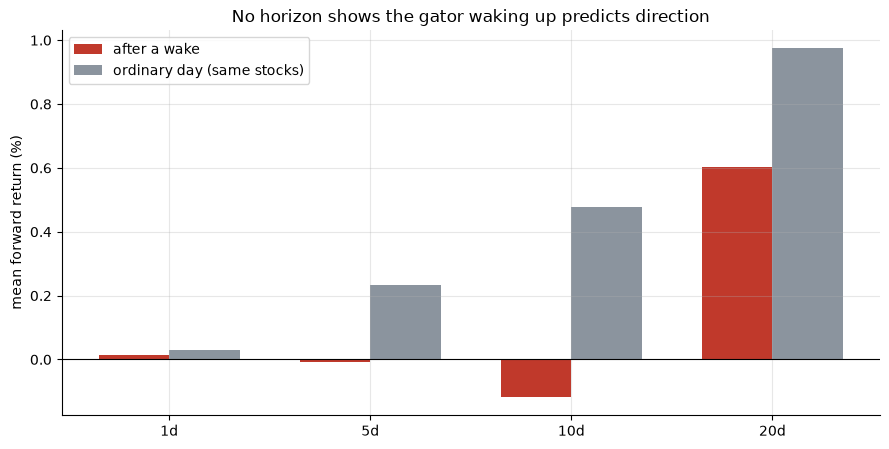

{1: (0.013, 0.03), 5: (-0.009, 0.233), 10: (-0.119, 0.479), 20: (0.604, 0.976)}


In [2]:
if HAVE_REAL:
    res = st.run_experiment(PANEL, horizons=st.HORIZONS, n_draws=1000)
    hs = list(res['horizon']); means = list(res['mean_signed']*100)
    bases = list(res['base_mean']*100)
else:
    hs = sorted(R['event']); means = [R['event'][h]['mean'] for h in hs]
    bases = [R['event'][h]['base'] for h in hs]
x = np.arange(len(hs)); w = 0.35
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x - w/2, means, width=w, color=RED, label='after a wake')
ax.bar(x + w/2, bases, width=w, color=GREY, label='ordinary day (same stocks)')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (%)')
ax.set_title('No horizon shows the gator waking up predicts direction')
ax.legend(); plt.tight_layout(); plt.show()
print({h: (round(m,3), round(b,3)) for h,m,b in zip(hs, means, bases)})

The 10-day bar (the same window the timer trades) shows the biggest gap — wake events return **-0.119%** vs **+0.479%** for an ordinary day — but that's a smaller number *behind* the ordinary day, and it's still not statistically distinguishable from luck (the quants notebook shows why: Welch *t* = -1.88, short of the ±2 bar).

**What about the "a bigger move is coming" fallback** — maybe the Gator can't call direction, but does it at least flag more action ahead?

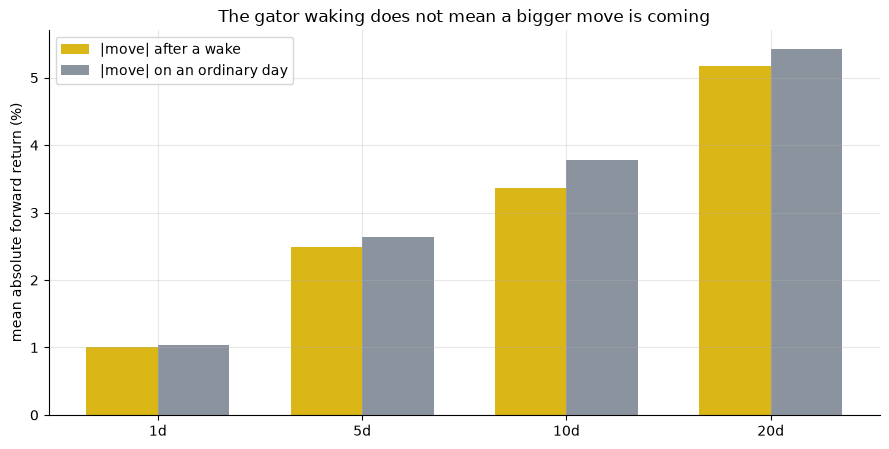

10-day: after wake 3.364   ordinary 3.785


In [3]:
if HAVE_REAL:
    a, b = res['mean_abs']*100, res['base_abs']*100
else:
    a = [R['event'][h]['mean_abs'] for h in hs]
    b = [R['event'][h]['base_abs'] for h in hs]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x - w/2, a, width=w, color=AMBER, label='|move| after a wake')
ax.bar(x + w/2, b, width=w, color=GREY, label='|move| on an ordinary day')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean absolute forward return (%)')
ax.set_title('The gator waking does not mean a bigger move is coming')
ax.legend(); plt.tight_layout(); plt.show()
print('10-day: after wake', round(list(a)[2] if HAVE_REAL else a[2],3),
      '  ordinary', round(list(b)[2] if HAVE_REAL else b[2],3))

If anything, the 10-day move after a wake is *smaller* than an ordinary day's — the opposite of "trend capture." Not a robust pattern across every horizon, but there is certainly no sign of the promised bigger move.

**Finally, the trade.** This is where the story gets genuinely tricky — because on the surface, it looks like the Gator *works beautifully*:

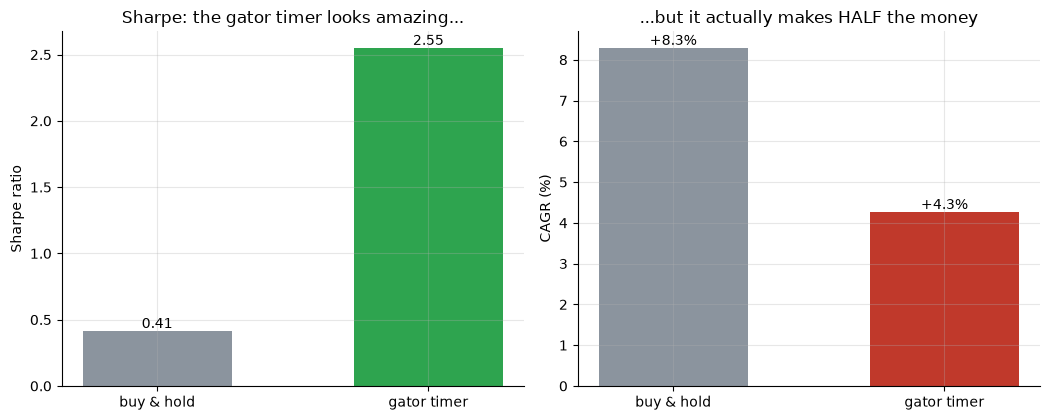

Sharpe: BH 0.41  Gator timer 2.55  |  CAGR: BH +8.3%  Gator timer +4.3%


In [4]:
if HAVE_REAL:
    out = st.run_timer_experiment(SPY, placebo=False)
    bh_s, wk_s = out['bh']['sharpe'], out['wake']['sharpe']
    bh_c, wk_c = out['bh']['cagr']*100, out['wake']['cagr']*100
else:
    bh_s, wk_s = R['bh']['sharpe'], R['wake']['sharpe']
    bh_c, wk_c = R['bh']['cagr'], R['wake']['cagr']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['buy & hold','gator timer'], [bh_s, wk_s], color=[GREY, GREEN], width=.55)
for i,v in enumerate([bh_s, wk_s]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_title('Sharpe: the gator timer looks amazing...'); a1.set_ylabel('Sharpe ratio')
a2.bar(['buy & hold','gator timer'], [bh_c, wk_c], color=[GREY, RED], width=.55)
for i,v in enumerate([bh_c, wk_c]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_title('...but it actually makes HALF the money'); a2.set_ylabel('CAGR (%)')
plt.tight_layout(); plt.show()
print(f'Sharpe: BH {bh_s:.2f}  Gator timer {wk_s:.2f}  |  CAGR: BH {bh_c:+.1f}%  Gator timer {wk_c:+.1f}%')

A Sharpe of **2.55** against buy-and-hold's **0.41** looks like a knockout. But look at the CAGR chart right next to it: the gator timer makes **+4.3%/yr**, buy-and-hold makes **+8.3%/yr** — roughly *double*. How can the "worse" strategy have the better Sharpe? Because it's sitting in cash **90%** of the time (only **13** genuine wakes fired on SPY in 26.5 years), earning a smooth, riskless 4%/yr on almost every day. A portfolio that's mostly cash has tiny volatility almost by definition — and Sharpe rewards low volatility, no matter where it comes from. Test it the honest way (does it actually beat buy-and-hold, statistically?) and the advantage vanishes — the quants notebook shows exactly how.

## 5 · The verdict

- **Signal — None.** No horizon (1/5/10/20 days) after a genuine wake shows a statistically real directional edge, and the "bigger move coming" fallback doesn't hold up either.
- **Tradability — Mirage.** The eye-catching Sharpe on a real SPY timer is a side-effect of sitting mostly in cash, not a genuine trading edge — it doesn't beat buy-and-hold once tested properly, and doesn't beat simply staying in the Alligator's fan the whole time either.
- **"Does the gator's awakening catch the start of a trend?" — Busted.** We proved the detector *can* catch a real planted trend in a controlled experiment — so it's not that the method is broken. It's that on real markets, there's nothing there to catch.

## 6 · Going further 🚪

- **The Gator adds a layer of decoration, not information.** It's built entirely from the same three lines as [study 421](../../421-williams-alligator/) — any signal it could carry is already inside those lines. If a trend-following signal exists in the Alligator fan, watching for the specific moment the histogram changes color doesn't seem to time it any better.
- **Why the Sharpe trap matters beyond this study.** Any strategy that's mostly in cash will tend to show an inflated Sharpe against a fully-invested benchmark — always check the *difference* is statistically real, and always look at the actual return, not just the ratio.
- **Sibling studies:** [421-williams-alligator](../../421-williams-alligator/) (the fan itself), [184-williams-fractals](../../184-williams-fractals/) (a different Williams pivot marker), [420-awesome-oscillator](../../420-awesome-oscillator/) and [474-accelerator-oscillator](../../474-accelerator-oscillator/) (Williams' momentum cousins) — none of them is this study.

*Think the Gator works on a different holding period or a different market? Show a signed forward-return edge that clears |t| ≥ 2 net of costs — then we'll talk.*